<a href="https://colab.research.google.com/github/MelisaYasak/transformer_arch/blob/main/transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scaled Dot-Product Attention
Transformer mimarisini çekirdeği scaled dot-product attention formülüdür.

Bu formül:

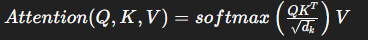

şeklindedir.

Scaled dot-product attention aslında oldukça sezgisel bir fikirdir. Formül bize şunu anlatıyor: Bir kelimenin cümledeki diğer kelimelere ne kadar “bakması” gerektiğini hesaplıyor. Bunu yaparken her kelimeyi üç farklı vektörle temsil ediyoruz: Query (sorgu), Key (anahtar) ve Value (değer).

Önce Query vektörünü alıp tüm Key vektörleriyle karşılaştırıyoruz. Bu karşılaştırma, noktasal çarpım ile yapılıyor ve bize kelimeler arasındaki benzerlik skorlarını veriyor. Bu skorlar bazen çok büyüyebileceği için, vektör boyutu (dₖ) ile bölünerek dengeleniyor.

Sonrasında bu değerleri softmax fonksiyonundan geçiriyoruz. Böylece skorlar, toplamı 1 olan dikkat ağırlıklarına dönüşüyor. En son adımda ise bu ağırlıkları Value vektörleriyle birleştirerek her kelimenin, diğer kelimelerden etkilenmiş yeni bir temsiline ulaşıyoruz.

In [ ]:
import torch
import torch.nn.functional as F


In [ ]:
def sdp_attention(q,k,v):
  d_k = q.size(-1)
  scores = torch.matmul(q, k.transpose(-2,-1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
  weight = F.softmax(scores, dim=-1)
  output = torch.matmul(weight, v)
  return output, weight

Şimdi bir örnek ile formülü çalıştıralım. Q,K ve V vektörlerini (batch, seq_len, d_model) olacak şekilde random oluşturalım

In [ ]:
Q = torch.rand(1, 3, 4)
K = torch.rand(1, 3, 4)
V = torch.rand(1, 3, 4)
output, weights = sdp_attention(Q, K, V)

print("Output:", output)
print("Attention weights:", weights)

Output: tensor([[[0.3896, 0.6233, 0.7005, 0.6662],
         [0.3854, 0.6143, 0.6904, 0.6809],
         [0.3850, 0.6173, 0.6925, 0.6787]]])
Attention weights: tensor([[[0.3316, 0.3602, 0.3083],
         [0.3742, 0.3375, 0.2883],
         [0.3666, 0.3443, 0.2891]]])


### Weights
Burada weights tensörüne baktığımızda satırlar bir Query'i sütünler ile bakılan token'ı yani  Key'i temsil eder. Yani weights i okurken şunu düşünmeliyiz: X. token'ın yeni temsilini oluştururken diğer token'ların bilgisinden ne kadar katkı alıyor.

Örneğin weights[0,0,:] bakalım:

1. kelimenin yeni hali oluşurken
- %33 kendi bilgisinden
- %36 2. token'ın bilgisinden
- %30 3. token'ın bilgisinden geliyor


"1.token, temsilini oluştururken 2.tokenın value vektöründen %36 oranında katkı alıyor." cümlesini de kurabiliriz.

Fakat burada şu konuya dikkat edilmeli. Katkı alıyor ifadesi her token bilgisinden de katı aldığını söyler. Yani ağırlığı yüksek olanı alıyor gibi bir yanılgıya düşülmemelidir. Bu ağırlık miktarları kadar hepsinin bilgisini karıştırarak yeni token üretilmektedir. Aslında klasik regresyon formülü çalışır burada (y = Σ( aᵢxᵢ ) + b)


### Output
Output tensörü işe her token'ın diğer tokenlardan bilgi toplayarak oluşturduğu yeni temsildir. Her satır yeni token'ların embeddingini ifade eder. Artık token'lar input olarak verdiğimiz şekilde sadece kendilerinin embeddinglerini değil context-aware hallerini temsil ederler. Yani artık token'ların anlamı context'e göre değişti.